In [1]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups

In [2]:
import numpy as np
import re
import nltk
from sklearn.datasets import fetch_20newsgroups
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [3]:
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [4]:
train_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
test_data = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

In [5]:
stop_words = set(stopwords.words('english'))

In [6]:
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    tokens = word_tokenize(text)
    return [word for word in tokens if word not in stop_words and len(word) > 2]

print("Preprocessing training data")
X_train_tokens = [preprocess_text(text) for text in train_data.data]
y_train = train_data.target

print("Preprocessing testing data")
X_test_tokens = [preprocess_text(text) for text in test_data.data]
y_test = test_data.target

Preprocessing training data
Preprocessing testing data


In [7]:
from gensim.models import Word2Vec

In [8]:
w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=2, workers=4)
#traning Word2vec Model

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [10]:
def document_vector(doc_tokens, model):
    valid_words = [word for word in doc_tokens if word in model.wv]
    if not valid_words:
        return np.zeros(model.vector_size)
    
    word_vecs = [model.wv[word] for word in valid_words]
    return np.mean(word_vecs, axis=0)

In [11]:
X_train_w2v = np.array([document_vector(doc, w2v_model) for doc in X_train_tokens])
X_test_w2v = np.array([document_vector(doc, w2v_model) for doc in X_test_tokens])

print(f"Training data shape: {X_train_w2v.shape}") 

Training data shape: (11314, 100)


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

In [13]:
X_train_tensor = torch.FloatTensor(X_train_w2v)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_w2v)
y_test_tensor = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)

In [14]:
X_train_tensor = torch.FloatTensor(X_train_w2v)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_w2v)
y_test_tensor = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)

class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        hidden = self.relu(self.layer1(x))
        out = self.layer2(hidden)
        return out, hidden

input_dim = 100 
hidden_dim = 64
num_classes = 20

model = SimpleNN(input_dim, hidden_dim, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

epochs = 15
hidden_vectors_epoch1 = None
hidden_vectors_final = None

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        _, hidden_test = model(X_test_tensor)
        if epoch == 0:
            hidden_vectors_epoch1 = hidden_test.numpy()
        if epoch == epochs - 1:
            hidden_vectors_final = hidden_test.numpy()
            
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

model.eval()
with torch.no_grad():
    outputs, _ = model(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)
    accuracy_w2v = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
print(f" NN Test Accuracy: {accuracy_w2v * 100:.2f}%")

Epoch 1/15, Loss: 2.2418
Epoch 2/15, Loss: 1.9840
Epoch 3/15, Loss: 1.9343
Epoch 4/15, Loss: 1.9044
Epoch 5/15, Loss: 1.8747
Epoch 6/15, Loss: 1.8561
Epoch 7/15, Loss: 1.8455
Epoch 8/15, Loss: 1.8278
Epoch 9/15, Loss: 1.8247
Epoch 10/15, Loss: 1.8159
Epoch 11/15, Loss: 1.8062
Epoch 12/15, Loss: 1.7893
Epoch 13/15, Loss: 1.7857
Epoch 14/15, Loss: 1.7761
Epoch 15/15, Loss: 1.7710
 NN Test Accuracy: 37.28%


In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

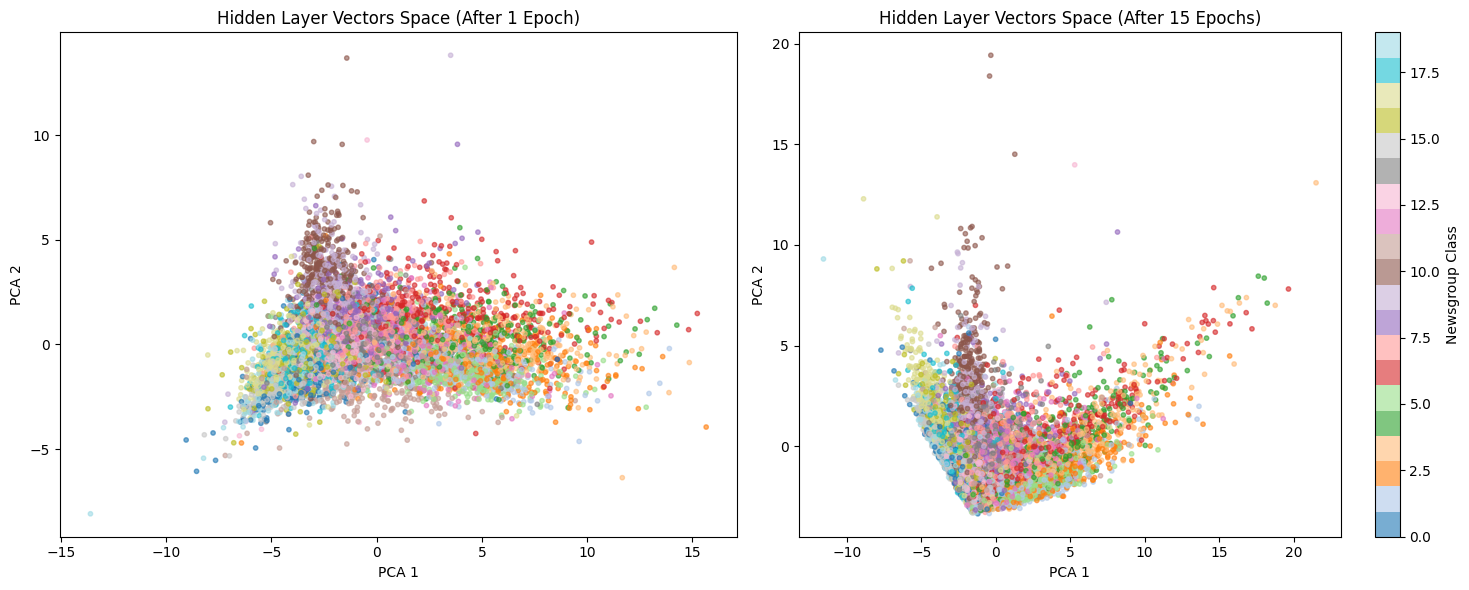

In [17]:
pca = PCA(n_components=2)

pca_epoch1 = pca.fit_transform(hidden_vectors_epoch1)
pca_final = pca.fit_transform(hidden_vectors_final)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

scatter1 = ax1.scatter(pca_epoch1[:, 0], pca_epoch1[:, 1], c=y_test, cmap='tab20', alpha=0.6, s=10)
ax1.set_title("Hidden Layer Vectors Space (After 1 Epoch)")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")

scatter2 = ax2.scatter(pca_final[:, 0], pca_final[:, 1], c=y_test, cmap='tab20', alpha=0.6, s=10)
ax2.set_title(f"Hidden Layer Vectors Space (After {epochs} Epochs)")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")

plt.colorbar(scatter2, ax=ax2, label="Newsgroup Class")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
print("Vectorizing using TF-IDF")
X_train_strings = [" ".join(doc) for doc in X_train_tokens]
X_test_strings = [" ".join(doc) for doc in X_test_tokens]

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_strings).toarray()
X_test_tfidf = tfidf.transform(X_test_strings).toarray()

X_train_tfidf_tensor = torch.FloatTensor(X_train_tfidf)
X_test_tfidf_tensor = torch.FloatTensor(X_test_tfidf)

train_loader_tfidf = DataLoader(TensorDataset(X_train_tfidf_tensor, y_train_tensor), batch_size=64, shuffle=True)

model_tfidf = SimpleNN(input_size=5000, hidden_size=64, num_classes=20)
optimizer_tfidf = optim.Adam(model_tfidf.parameters(), lr=0.005)

print("Training TF-IDF Neural Network")
for epoch in range(epochs):
    model_tfidf.train()
    for inputs, labels in train_loader_tfidf:
        optimizer_tfidf.zero_grad()
        outputs, _ = model_tfidf(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_tfidf.step()

# Evaluate TF-IDF
model_tfidf.eval()
with torch.no_grad():
    outputs, _ = model_tfidf(X_test_tfidf_tensor)
    _, predicted = torch.max(outputs.data, 1)
    accuracy_tfidf = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)

print(f"\nFinal TF-IDF NN Test Accuracy: {accuracy_tfidf * 100:.2f}%")
print(f"Final Word2Vec NN Test Accuracy (from earlier): {accuracy_w2v * 100:.2f}%")

print("""
--- Discussion: What are the differences? ---
TF-IDF usually outperforms simple averaged Word2Vec on the 20 Newsgroups dataset. 
Word2Vec captures semantic meaning, but averaging all word vectors in a long document 
dilutes the specific keywords that identify a topic (e.g., 'hardware', 'god', 'space'). 
TF-IDF explicitly heavily weights rare, highly-specific keywords, giving the neural 
network much clearer signals for pure topic classification.
""")